# Trained PPO -- PRB demand & QoS before/after, all controllable scenarios

Loads the trained checkpoint `models/upper_ppo_single_scenario_tight_std/run_20260702_141129/upper_ppo_best.zip`
and runs it deterministically through all 7 controllable scenarios (10 episodes each, via
`run_trained_policy_eval.py` -> `results/trained_ppo_tight_std_eval/*_trained_policy_trace.csv`).
This notebook plots, per scenario and per gNB, PRB **demand** before/after and **used/served** PRB
before/after -- i.e. what the network wanted vs. got, at the start and end of each decision window.

**Same caveat as the comparison notebook:** this checkpoint is trained on `jain_balance_controllable`
only and was a mid-training snapshot when saved -- its deterministic action currently triggers zero
handovers on every scenario (see `notebooks/compare_baseline_heuristic_trained.ipynb`), so "before" and
"after" PRB demand will look identical here. What *does* move slightly between before/after is the
served/used PRB, which reflects scheduler dynamics within the window rather than any rebalancing action.


In [ ]:
import os
from pathlib import Path

# Make this notebook runnable regardless of the kernel's working directory
# (e.g. VSCode/Jupyter often start in notebooks/, not the repo root).
if not Path('results').exists():
    os.chdir(Path.cwd().parent)

import pandas as pd, glob

files = sorted(glob.glob('results/trained_ppo_tight_std_eval/*_trained_policy_trace.csv'))
qos_rows = []
for f in files:
    df = pd.read_csv(f)
    scen = df['scenario_name'].iloc[0]
    qos_rows.append({
        'scenario': scen,
        'throughput_mbps': df['network_throughput_mbps'].mean(),
        'delivery_ratio': df['network_delivery_ratio'].mean(),
        'mean_hol_delay_ms': df['network_mean_hol_delay_ms'].mean(),
        'sla_severity': df['sla_severity'].mean(),
        'jain_fairness_raw': df['jain_fairness_raw'].mean(),
        'handover_count': df['handover_count'].mean(),
    })
qos_df = pd.DataFrame(qos_rows).set_index('scenario')
qos_df.round(3)


                           throughput_mbps  delivery_ratio  mean_hol_delay_ms  sla_severity  jain_fairness_raw  handover_count
scenario                                                                                                                      
jain_balance_controllable           67.684           0.991              9.017         0.000              0.333             0.0
jain_control_embb_mmtc              56.783           1.000              0.158         0.000              0.333             0.0
jain_control_embb_urllc             51.545           0.999              0.342         0.001              0.333             0.0
jain_control_mixed                  61.994           0.905             66.367         0.034              0.333             0.0
jain_control_mmtc                   40.489           1.000              0.100         0.000              0.333             0.0
jain_control_urllc_mmtc             42.524           0.999              0.667         0.003              0.333 

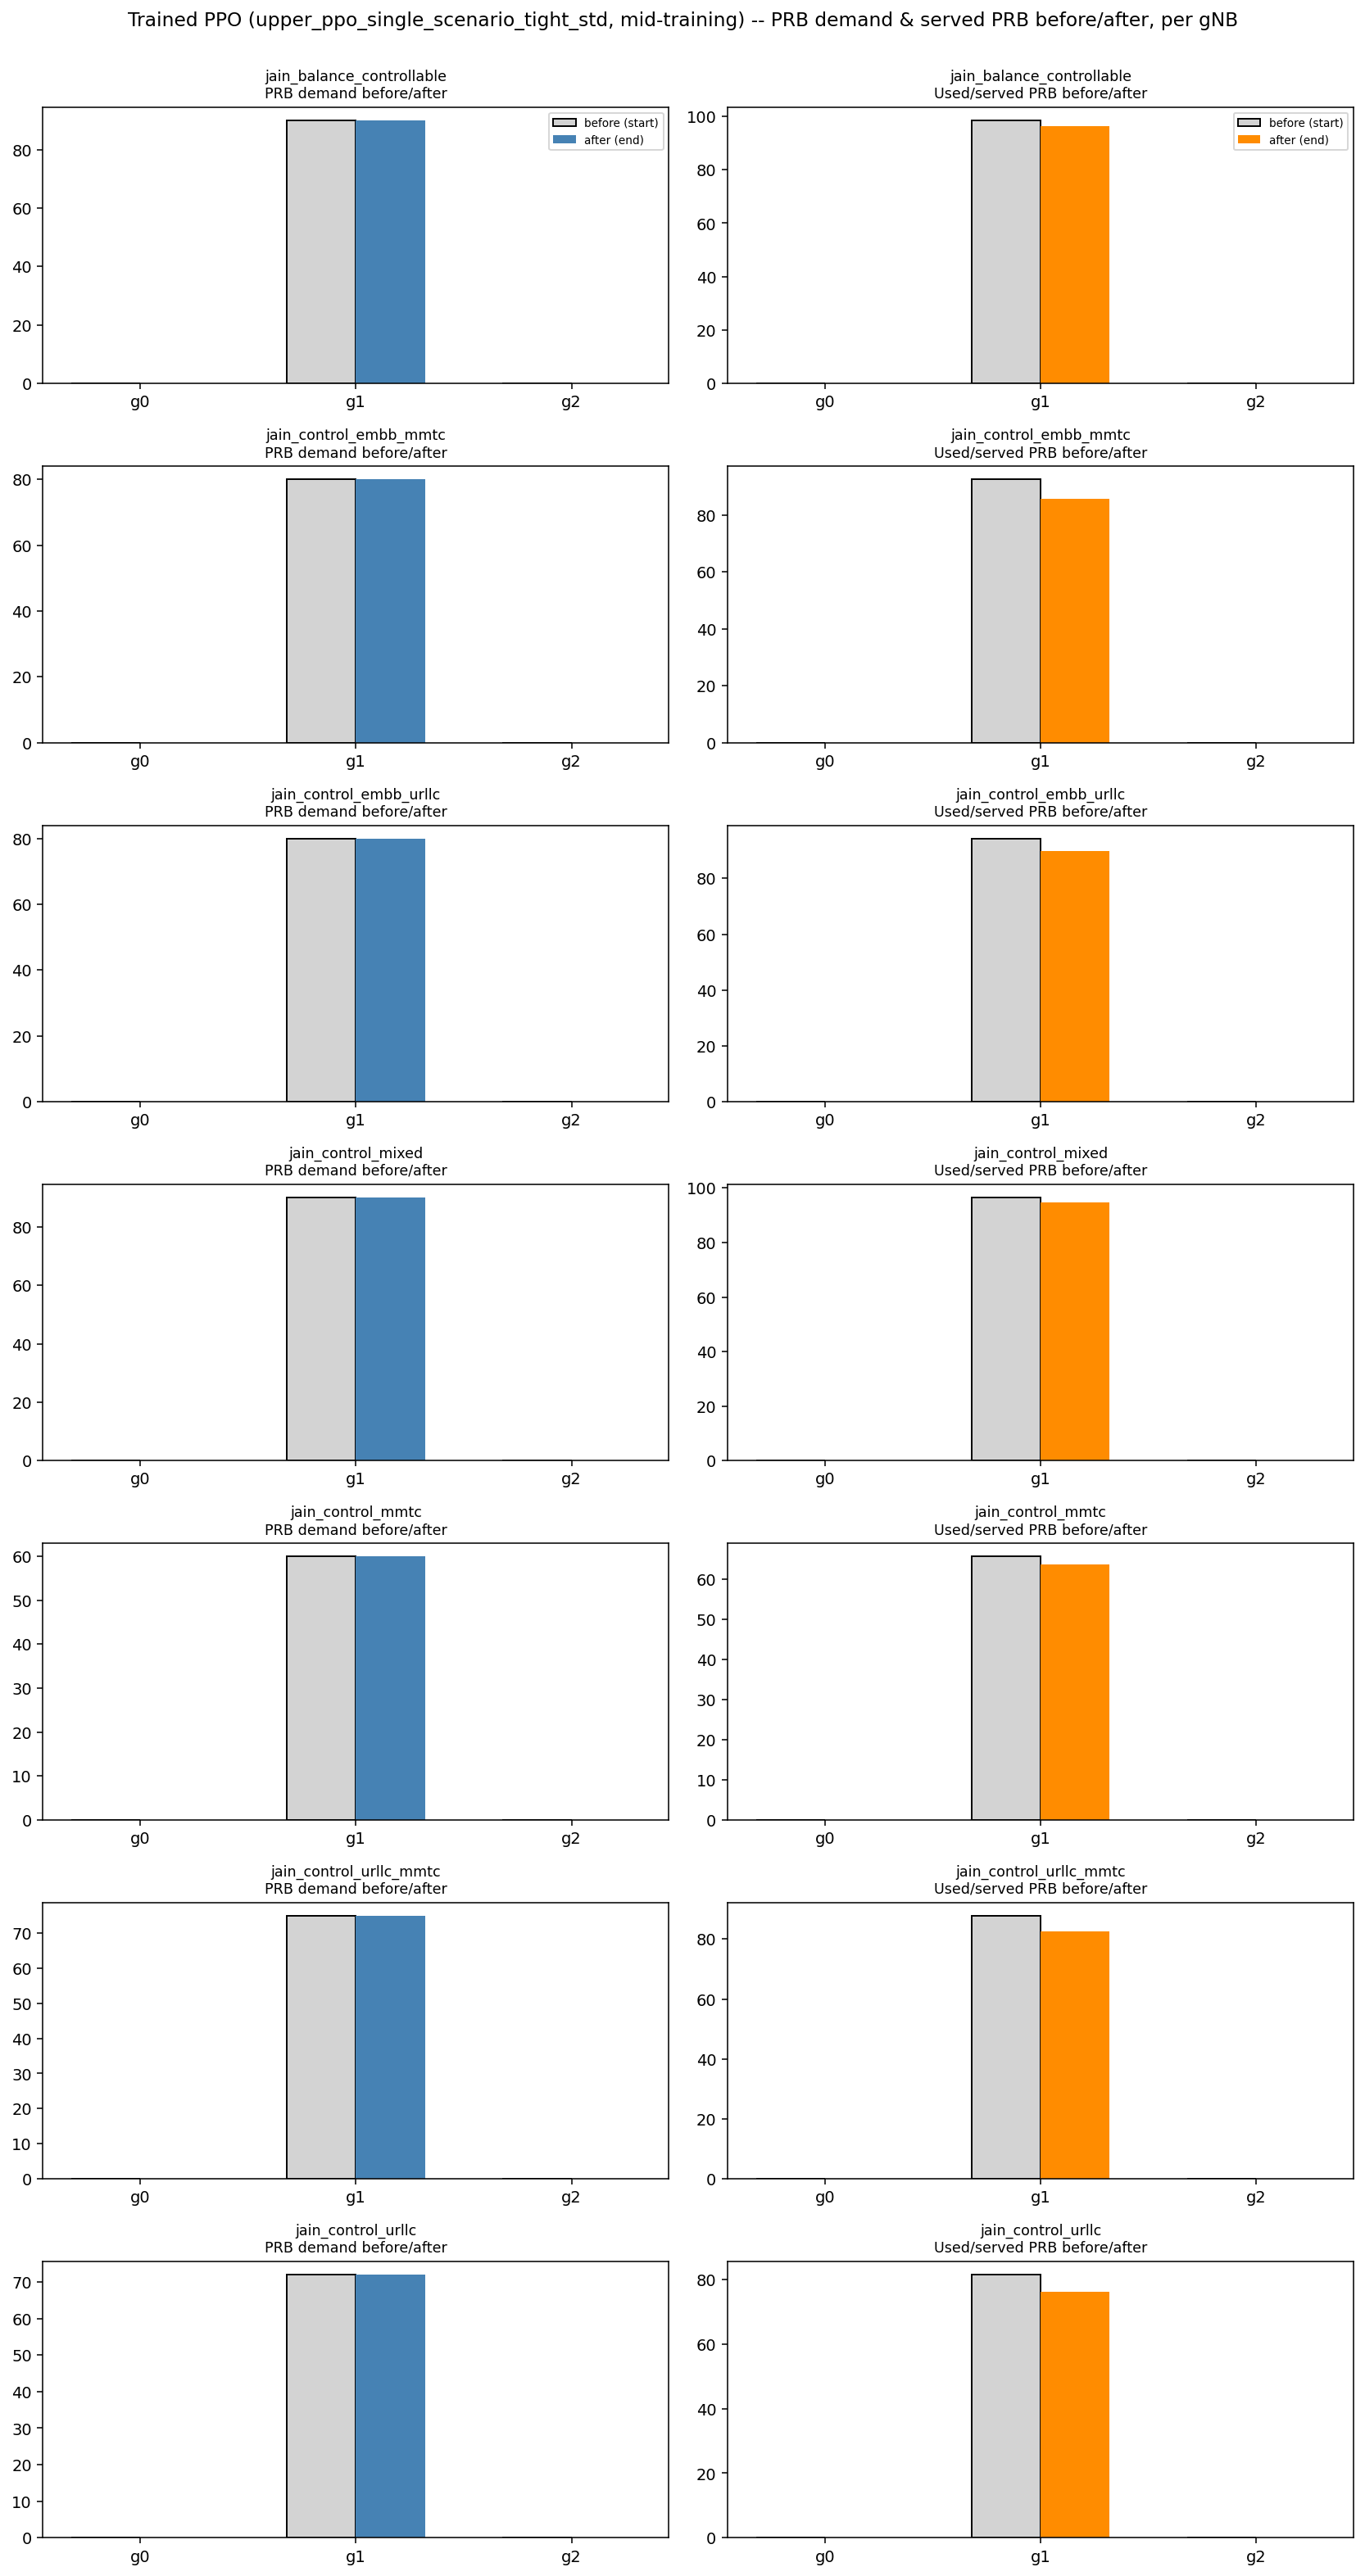

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

scenarios, demand_start, demand_end, used_start, used_end = [], [], [], [], []
for f in files:
    df = pd.read_csv(f)
    scen = df['scenario_name'].iloc[0]
    scenarios.append(scen)
    demand_start.append([df[f'gnb_demand_prb_start_g{i}'].mean() for i in range(3)])
    demand_end.append([df[f'gnb_demand_prb_end_g{i}'].mean() for i in range(3)])
    used_start.append([df[f'gnb_used_prb_start_g{i}'].mean() for i in range(3)])
    used_end.append([df[f'gnb_used_prb_end_g{i}'].mean() for i in range(3)])

demand_start, demand_end = np.array(demand_start), np.array(demand_end)
used_start, used_end = np.array(used_start), np.array(used_end)

n = len(scenarios)
fig, axes = plt.subplots(n, 2, figsize=(12, 3.2 * n))
gnb_labels = ['g0', 'g1', 'g2']
x = np.arange(3)
width = 0.32

for i, scen in enumerate(scenarios):
    ax = axes[i, 0]
    ax.bar(x - width/2, demand_start[i], width, label='before (start)', color='lightgray', edgecolor='black')
    ax.bar(x + width/2, demand_end[i], width, label='after (end)', color='steelblue')
    ax.set_xticks(x); ax.set_xticklabels(gnb_labels)
    ax.set_title(f'{scen}\nPRB demand before/after', fontsize=9)
    if i == 0:
        ax.legend(fontsize=7)

    ax = axes[i, 1]
    ax.bar(x - width/2, used_start[i], width, label='before (start)', color='lightgray', edgecolor='black')
    ax.bar(x + width/2, used_end[i], width, label='after (end)', color='darkorange')
    ax.set_xticks(x); ax.set_xticklabels(gnb_labels)
    ax.set_title(f'{scen}\nUsed/served PRB before/after', fontsize=9)
    if i == 0:
        ax.legend(fontsize=7)

fig.suptitle('Trained PPO (upper_ppo_single_scenario_tight_std, mid-training) -- PRB demand & served PRB before/after, per gNB', fontsize=12, y=1.001)
fig.tight_layout()
plt.show()


## Findings

- **PRB demand before == after, on every scenario.** All demand stays parked on gNB1 (`g1`), start
  and end bars are visually identical -- consistent with `handover_count=0` in the deterministic
  evaluation: no UE ever moved gNB, so demand couldn't shift either.
- **Used/served PRB drifts down slightly from start to end even with zero handovers** -- e.g.
  `jain_control_mmtc` ~65->~63, `jain_control_urllc` ~82->~76, `jain_control_urllc_mmtc` ~87->~83.
  This isn't rebalancing -- it's scheduler/service dynamics within the window (SINR/PF-scheduling
  fluctuation) acting on a load that never physically moved. Worth remembering when reading QoS
  deltas for *any* policy: not all "before/after" movement in used PRB implies a handover happened.
- **`jain_control_mixed` remains the stress case**: lowest delivery ratio (0.905) and by far the
  highest mean HOL delay (66.4 ms) of the seven, and the highest SLA severity (0.034) -- even though
  demand there is fully static too. This matches the zero-action baseline's own weak point on this
  scenario, reinforcing that `jain_control_mixed`'s difficulty comes from raw demand volume, not from
  imbalance this checkpoint could fix (since it isn't fixing anything yet).
- Bottom line unchanged from the comparison notebook: this checkpoint isn't acting, so "before vs
  after" here is really just measuring passive network dynamics under a static, unbalanced load. This
  notebook is worth re-running once the `tight_std` training run progresses -- that's when before/after
  PRB demand should actually start to diverge.
